# सिनैप्टिक रूटिंग आर्किटेक्चर (एसआरए) क्विकस्टार्ट

यह नोटबुक एसआरए के बुनियादी तंत्र और इसकी मुख्य विशेषता, 'रूटिंग' व्यवहार को आसानी से अनुभव करने का एक डेमो है।
आप Google Colab जैसे वातावरण में शीर्ष से क्रम में कोशिकाओं को चलाकर एसआरए के व्यवहार का निरीक्षण कर सकते हैं।

## 1. पर्यावरण सेटअप
यदि आप इसे Google Colab पर चला रहे हैं, तो रिपॉजिटरी को क्लोन करने और आवश्यक लाइब्रेरी स्थापित करने के लिए निम्नलिखित सेल को निष्पादित करें।

In [1]:
# Run only in Colab environment (skip if local)
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

# Add path
sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. पुस्तकालय आयात करें और मॉडल तैयार करें
SRA MoE (विशेषज्ञों का मिश्रण) मॉडल प्रारंभ करें।

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model with a small configuration
config = MoESRAConfig(
    vocab_size=100,
    d_model=64,
    n_layers=2,
    n_heads=4,
    num_synapses=4,  # 4 experts (synapses)
    k=2,       # Select 2 synapses per token
    max_seq_len=64
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
print("Model initialized!")

Using device: cpu
Model initialized!


## 3. डमी डेटा के साथ फॉरवर्ड पास और रूटिंग चेक
मनमाना डेटा इनपुट करें और जांचें कि मॉडल प्रत्येक सिनैप्स (विशेषज्ञ) तक कैसे पहुंचता है।

In [3]:
# Dummy data with batch size 2 and sequence length 10
x = torch.randint(0, config.vocab_size, (2, 10)).to(device)

model.eval()
with torch.no_grad():
    y_in = torch.cat([torch.full((x.size(0), 1), 1, dtype=torch.long, device=device), x[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
print("Output shape:", outputs.shape)
print("Number of layers with routing info:", len(routing_weights))

Output shape: torch.Size([2, 10, 100])
Number of layers with routing info: 2


## 4. रूटिंग विज़ुअलाइज़ेशन
हीटमैप के साथ कल्पना करें कि प्रत्येक इनपुट टोकन को एक विशिष्ट परत में किस सिनैप्स (विशेषज्ञ) पर रूट किया गया था।
* यहां हम प्रशिक्षण से पहले एक यादृच्छिक स्थिति में रूटिंग दिखाते हैं।जैसे-जैसे प्रशिक्षण आगे बढ़ता है और किसी कार्य में विशेषज्ञता मिलती है, यह रूटिंग एक पूर्वाग्रह (विशेषज्ञता) दिखाएगी।

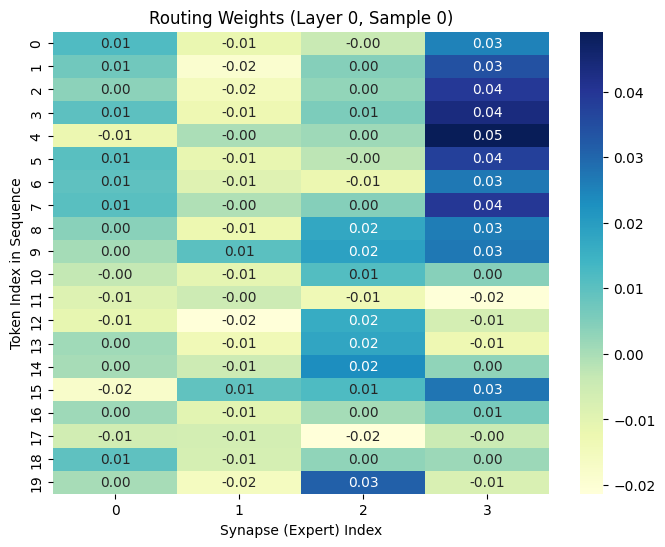

In [4]:
# Get routing weights of the first layer of the first sample
layer_idx = 0
sample_idx = 0
weights = routing_weights[layer_idx][sample_idx].cpu().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(weights, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title(f"Routing Weights (Layer {layer_idx}, Sample {sample_idx})")
plt.xlabel("Synapse (Expert) Index")
plt.ylabel("Token Index in Sequence")
plt.show()